# Material Informed Subgraph — Visualization

This notebook visualizes the **Material Informed Subgraph** as described in the paper.

The graph is loaded from `results/Query1/artifacts/subgraphs/2026041810_0_material_informed.json`.

In [1]:
import json
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

GRAPH_PATH = "../results/Query1/artifacts/subgraphs/2026041810_0_material_informed.json"

with open(GRAPH_PATH) as f:
    raw = json.load(f)

nodes = raw["data"]["nodes"]
edges = raw["data"].get("edges", raw["data"].get("links", []))
print(f"Loaded {len(nodes)} nodes and {len(edges)} edges")

Loaded 507 nodes and 8864 edges


In [2]:
G = nx.DiGraph()

for node in nodes:
    G.add_node(node["id"], **{k: v for k, v in node.items() if k != "id"})

for edge in edges:
    G.add_edge(edge["source"], edge["target"],
               relation=edge.get("relation", ""),
               source_kgs=edge.get("source_kgs", []))

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 507 nodes, 8864 edges


In [3]:
# --- Configuration ---
TOP_N = 80          # keep the N highest-degree nodes for readability
SEED   = 42
FIG_SIZE = (20, 16)

# Keep top-N nodes by degree so the plot stays legible
degree_sorted = sorted(G.degree(), key=lambda x: x[1], reverse=True)
top_nodes = [n for n, _ in degree_sorted[:TOP_N]]
H = G.subgraph(top_nodes).copy()
print(f"Material Informed Subgraph (top {TOP_N} nodes): {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")

Material Informed Subgraph (top 80 nodes): 80 nodes, 2038 edges


## Top-80 nodes by degree

To get a readable structural overview of the Material Informed Subgraph, the full graph is filtered down to the 80 highest-degree nodes (undirected degree), and the induced subgraph — containing all edges whose both endpoints survive the filter — is drawn.

**Layout:** Fruchterman–Reingold spring layout (`nx.spring_layout`). Nodes repel each other and edges act as springs, so tightly connected clusters pull together while loosely connected nodes spread apart. The `k` parameter (equilibrium spring length) is scaled as `1.8 / √N` to prevent central collapse at this node count.

**Node size** is proportional to the `size` attribute stored in the JSON, which reflects each node's degree in the full upstream knowledge graph — not just this subgraph. This means a node can appear large even if it has few edges visible here.

**Node colour** encodes semantic type (material, property, technique, etc.) via a fixed palette. Labels are shown only for the top-20 hubs to avoid overplotting.

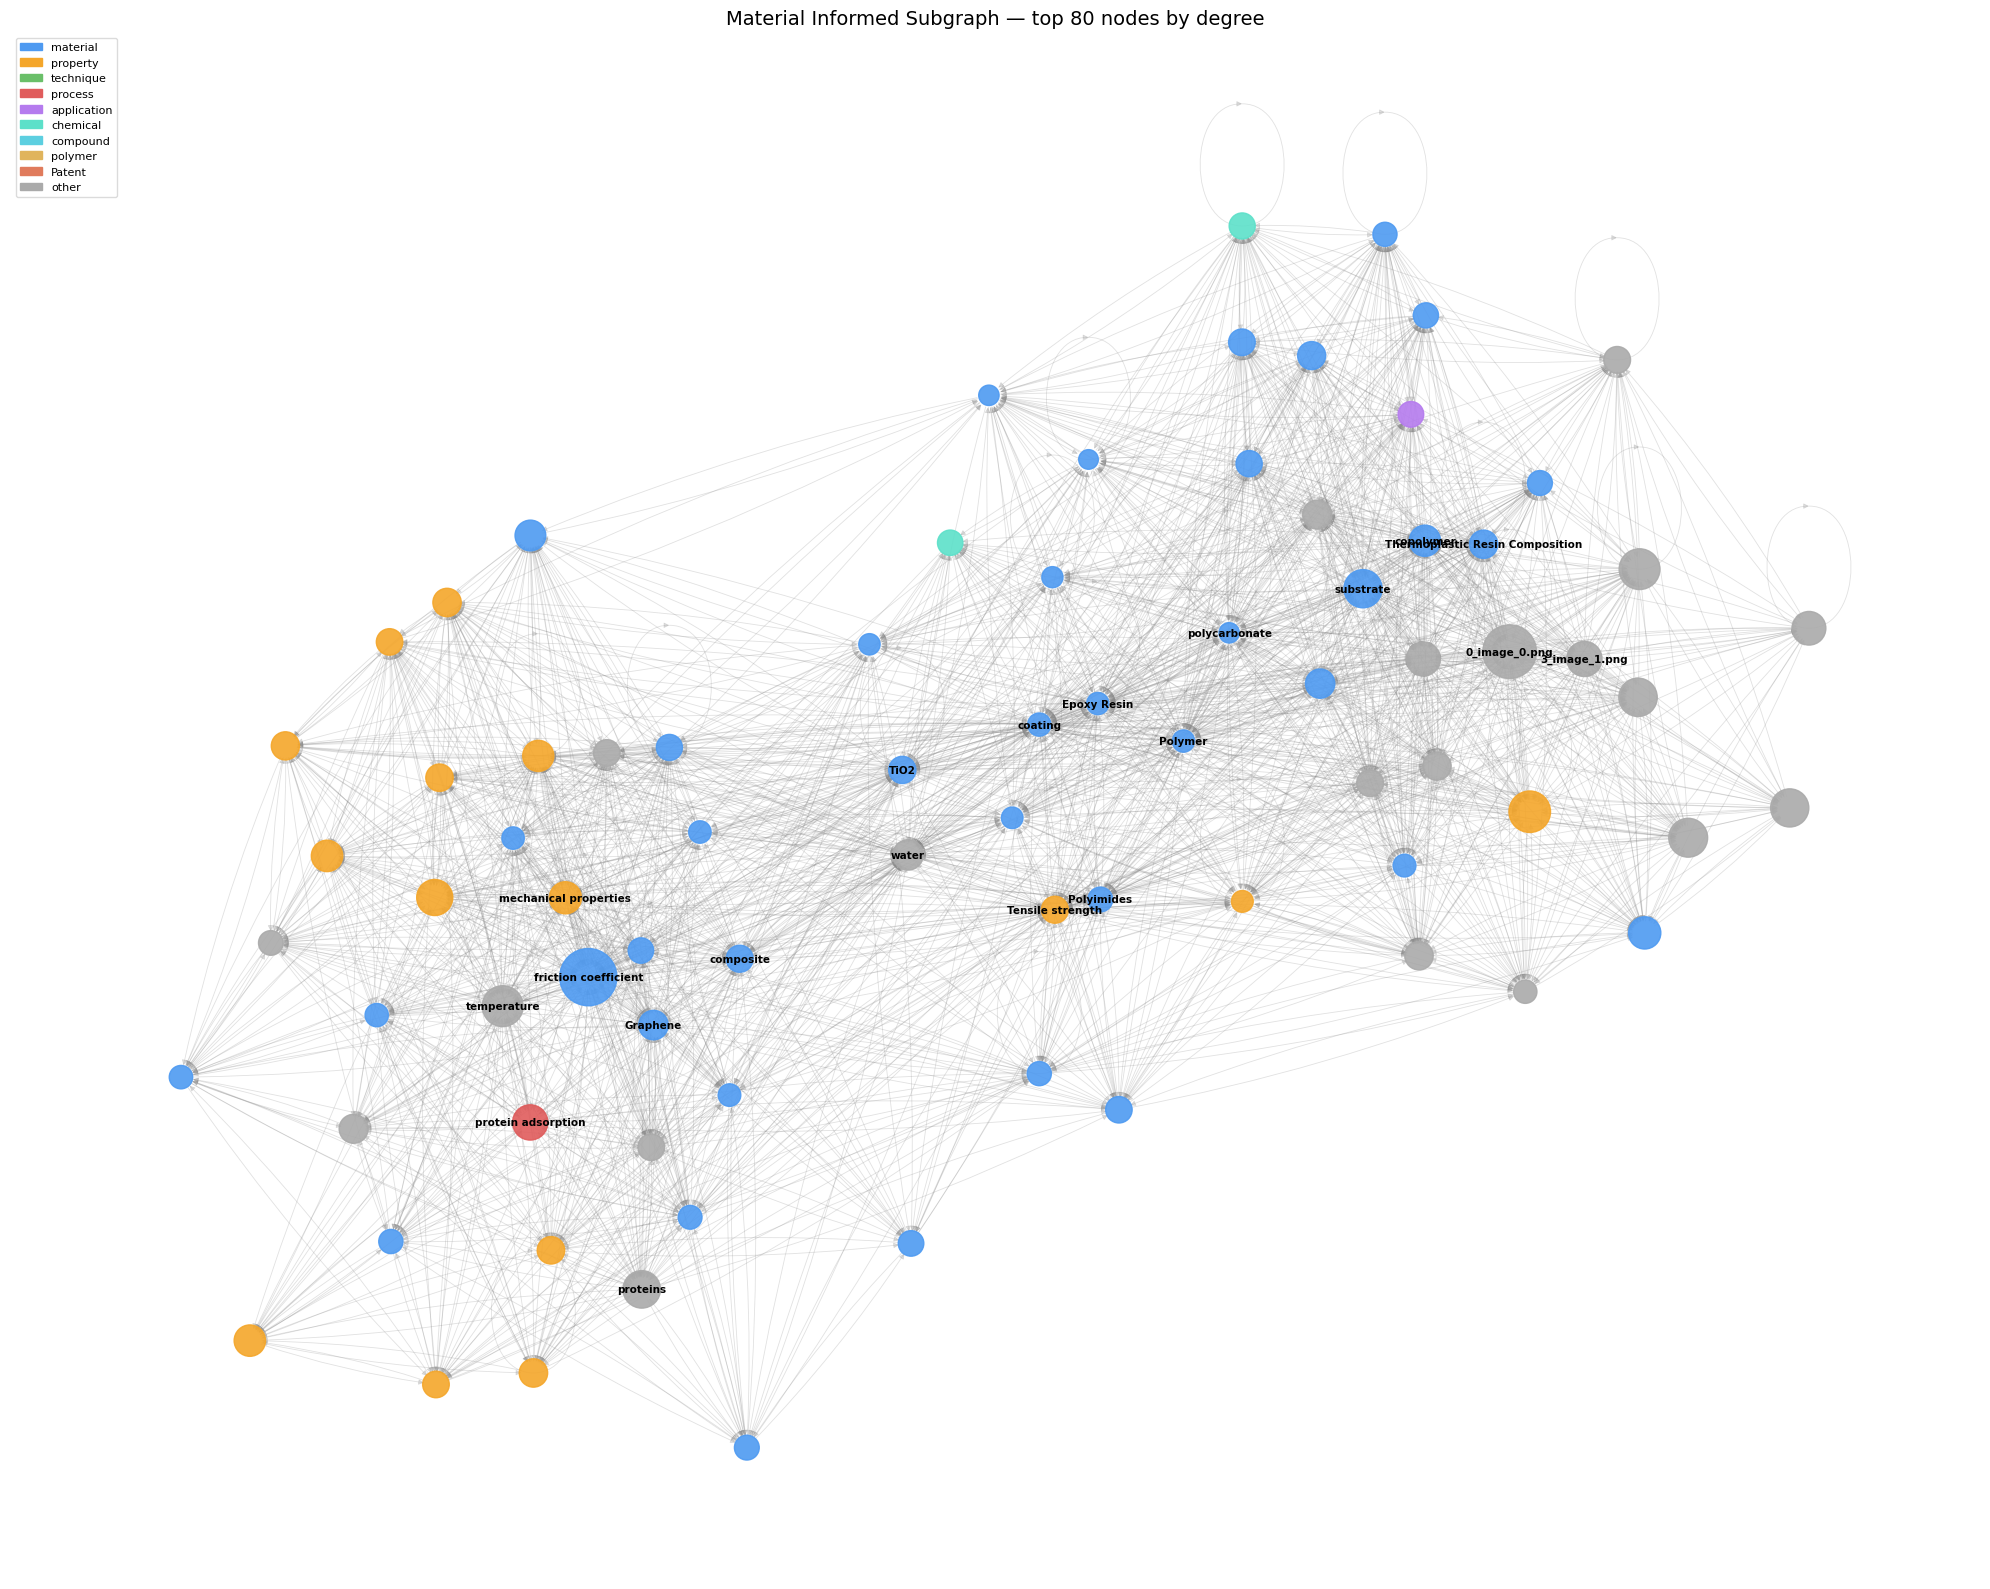

In [4]:
# ---- node colours by type ----
TYPE_COLORS = {
    "material":            "#4e9af1",
    "property":            "#f4a62a",
    "technique":           "#6abf69",
    "process":             "#e05c5c",
    "application":         "#b57bee",
    "chemical":            "#5ce0c9",
    "compound":            "#5ccfe0",
    "polymer":             "#e0b45c",
    "Patent":              "#e07b5c",
}
DEFAULT_COLOR = "#aaaaaa"

def node_color(n):
    t = H.nodes[n].get("type", "")
    for key, col in TYPE_COLORS.items():
        if key.lower() in t.lower():
            return col
    return DEFAULT_COLOR

node_colors = [node_color(n) for n in H.nodes]

# Size: scale by original `size` attribute (degree in full KG)
raw_sizes = np.array([H.nodes[n].get("size", 50) for n in H.nodes], dtype=float)
node_sizes = 200 + 1500 * (raw_sizes - raw_sizes.min()) / (raw_sizes.max() - raw_sizes.min() + 1e-9)

pos = nx.spring_layout(H, seed=SEED, k=1.8 / np.sqrt(len(H)))

fig, ax = plt.subplots(figsize=FIG_SIZE)

nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.25, width=0.6,
                       edge_color="#888888", arrows=True,
                       arrowsize=8, connectionstyle="arc3,rad=0.05")

nx.draw_networkx_nodes(H, pos, ax=ax,
                       node_color=node_colors, node_size=node_sizes, alpha=0.9)

# Labels only for the top-20 hubs
hub_nodes = {n: n for n, _ in degree_sorted[:20]}
nx.draw_networkx_labels(H, pos, labels=hub_nodes, ax=ax,
                        font_size=7.5, font_weight="bold")

# Legend
patches = [mpatches.Patch(color=col, label=t) for t, col in TYPE_COLORS.items()]
patches.append(mpatches.Patch(color=DEFAULT_COLOR, label="other"))
ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.7)

ax.set_title(f"Material Informed Subgraph — top {TOP_N} nodes by degree", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## 1-hop neighbourhood — Tensile strength

A single-node ego graph centred on **Tensile strength**. The neighbourhood is expanded on the *undirected* projection of the graph so that both incoming and outgoing edges are followed, giving all nodes within one hop regardless of edge direction. The induced directed subgraph is then drawn, preserving original edge directionality.

**Layout:** Fruchterman–Reingold with `k = 2.2 / √N`, giving more breathing room than the full overview since the node count is small.

**Edge colour** distinguishes structural role: red edges connect directly to the centre node; grey edges are cross-links between neighbours. **Edge labels** show the `relation` attribute (e.g. *"has property"*, *"measured by"*), making the semantic content of each connection explicit.

The centre node is rendered oversized and in red to anchor the eye. All other nodes follow the same type-colour scheme as the overview.

1-hop neighbourhood of 'Tensile strength': 86 nodes, 1210 edges


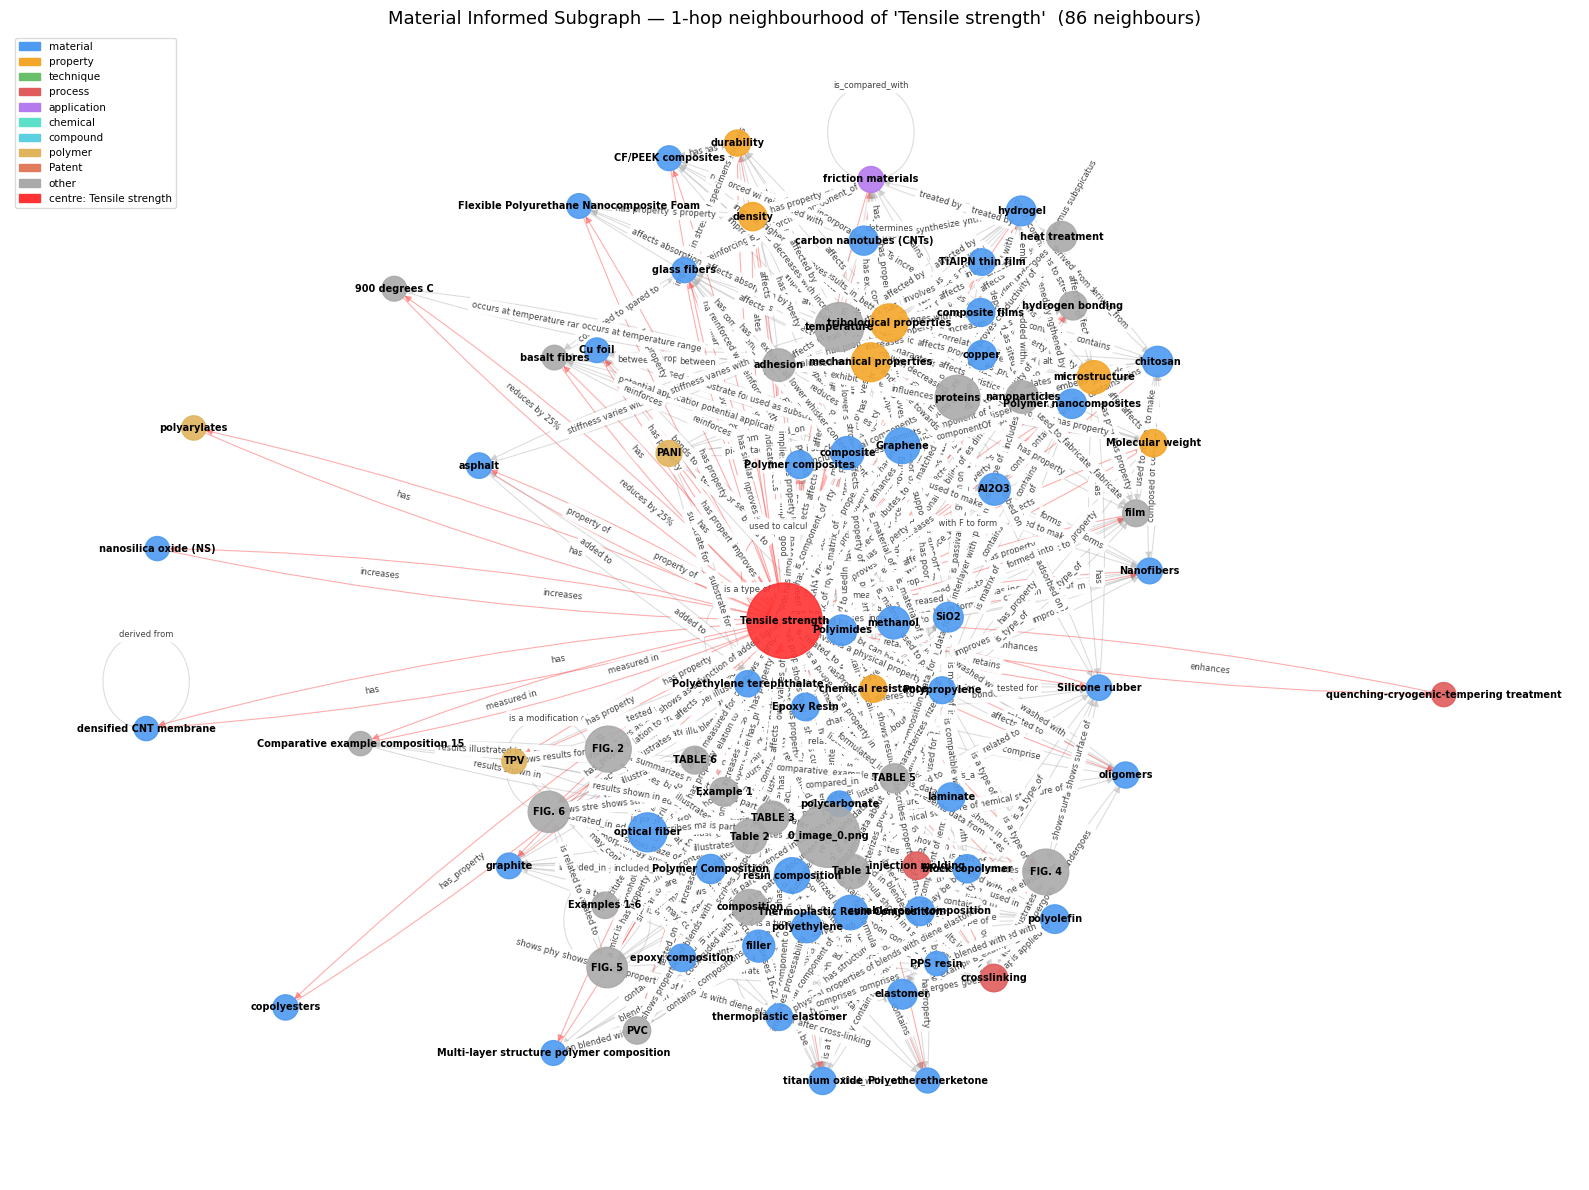

In [5]:
# ---- 1-hop neighbourhood around a node ----
CENTER_NODE = "Tensile strength"   # <-- change this to any node id
HOP_SEED    = 42
HOP_FIG_SIZE = (16, 12)

assert CENTER_NODE in G, f"Node '{CENTER_NODE}' not found. Available nodes: {list(G.nodes)[:10]} ..."

# Collect direct neighbours (treat as undirected so both in- and out-edges are included)
U = G.to_undirected()
hop1 = set(U.neighbors(CENTER_NODE))

neighbourhood = {CENTER_NODE} | hop1
S = G.subgraph(neighbourhood).copy()
print(f"1-hop neighbourhood of '{CENTER_NODE}': {S.number_of_nodes()} nodes, {S.number_of_edges()} edges")

# ---- colours: reuse TYPE_COLORS, highlight centre ----
def hop_node_color(n):
    if n == CENTER_NODE:
        return "#ff3333"
    t = S.nodes[n].get("type", "")
    for key, col in TYPE_COLORS.items():
        if key.lower() in t.lower():
            return col
    return DEFAULT_COLOR

hop_colors  = [hop_node_color(n) for n in S.nodes]
hop_raw_sz  = np.array([S.nodes[n].get("size", 50) for n in S.nodes], dtype=float)
hop_sizes   = 300 + 1800 * (hop_raw_sz - hop_raw_sz.min()) / (hop_raw_sz.max() - hop_raw_sz.min() + 1e-9)
# Make the centre node stand out
node_list = list(S.nodes)
for i, n in enumerate(node_list):
    if n == CENTER_NODE:
        hop_sizes[i] = max(hop_sizes) * 1.4

hop_pos = nx.spring_layout(S, seed=HOP_SEED, k=2.2 / np.sqrt(len(S)))

fig, ax = plt.subplots(figsize=HOP_FIG_SIZE)

# Colour edges: red if connected to centre, grey between neighbours
edge_colors = []
for u, v in S.edges():
    if u == CENTER_NODE or v == CENTER_NODE:
        edge_colors.append("#ff3333")
    else:
        edge_colors.append("#aaaaaa")

nx.draw_networkx_edges(S, hop_pos, ax=ax, alpha=0.4, width=0.8,
                       edge_color=edge_colors, arrows=True,
                       arrowsize=10, connectionstyle="arc3,rad=0.05")

nx.draw_networkx_nodes(S, hop_pos, ax=ax,
                       node_color=hop_colors, node_size=hop_sizes, alpha=0.9)

# Edge relation labels on all edges
edge_labels = {(u, v): S[u][v].get("relation", "") for u, v in S.edges()}
nx.draw_networkx_edge_labels(S, hop_pos, edge_labels=edge_labels, ax=ax,
                             font_size=6, label_pos=0.35, alpha=0.75)

nx.draw_networkx_labels(S, hop_pos, ax=ax, font_size=7, font_weight="bold")

# Legend
patches = [mpatches.Patch(color=col, label=t) for t, col in TYPE_COLORS.items()]
patches += [
    mpatches.Patch(color=DEFAULT_COLOR, label="other"),
    mpatches.Patch(color="#ff3333",     label=f"centre: {CENTER_NODE}"),
]
ax.legend(handles=patches, loc="upper left", fontsize=7.5, framealpha=0.7)

ax.set_title(
    f"Material Informed Subgraph — 1-hop neighbourhood of '{CENTER_NODE}'  ({len(hop1)} neighbours)",
    fontsize=13
)
ax.axis("off")
plt.tight_layout()
plt.show()


## Full graph

All 507 nodes and 8864 edges of the Material Informed Subgraph rendered in a single plot. At this scale the primary goal is to reveal **global topology** — cluster structure, density distribution, and the position of major hubs — rather than individual node identities.

**Layout:** Fruchterman–Reingold with `iterations=40` (reduced from the default 50) to keep runtime under ~20 seconds. The equilibrium spring length `k = 1.5 / √N` is tuned slightly tighter than the filtered view to prevent the graph from collapsing into a hairball at the centre.

**Edges** are drawn without arrowheads at `alpha=0.04` and `width=0.3`. At this density (~17 edges per node on average), any higher opacity turns the edge layer into a solid mass; the very low alpha instead renders the edge structure as a faint texture that conveys connectivity without obscuring nodes.

**Node size** uses the same `size`-attribute scaling as the filtered view, compressed into a 30–330 px² range so small nodes remain visible. Only the top 12 hubs by degree are labelled, each with a semi-transparent white background box to remain legible against the edge texture.

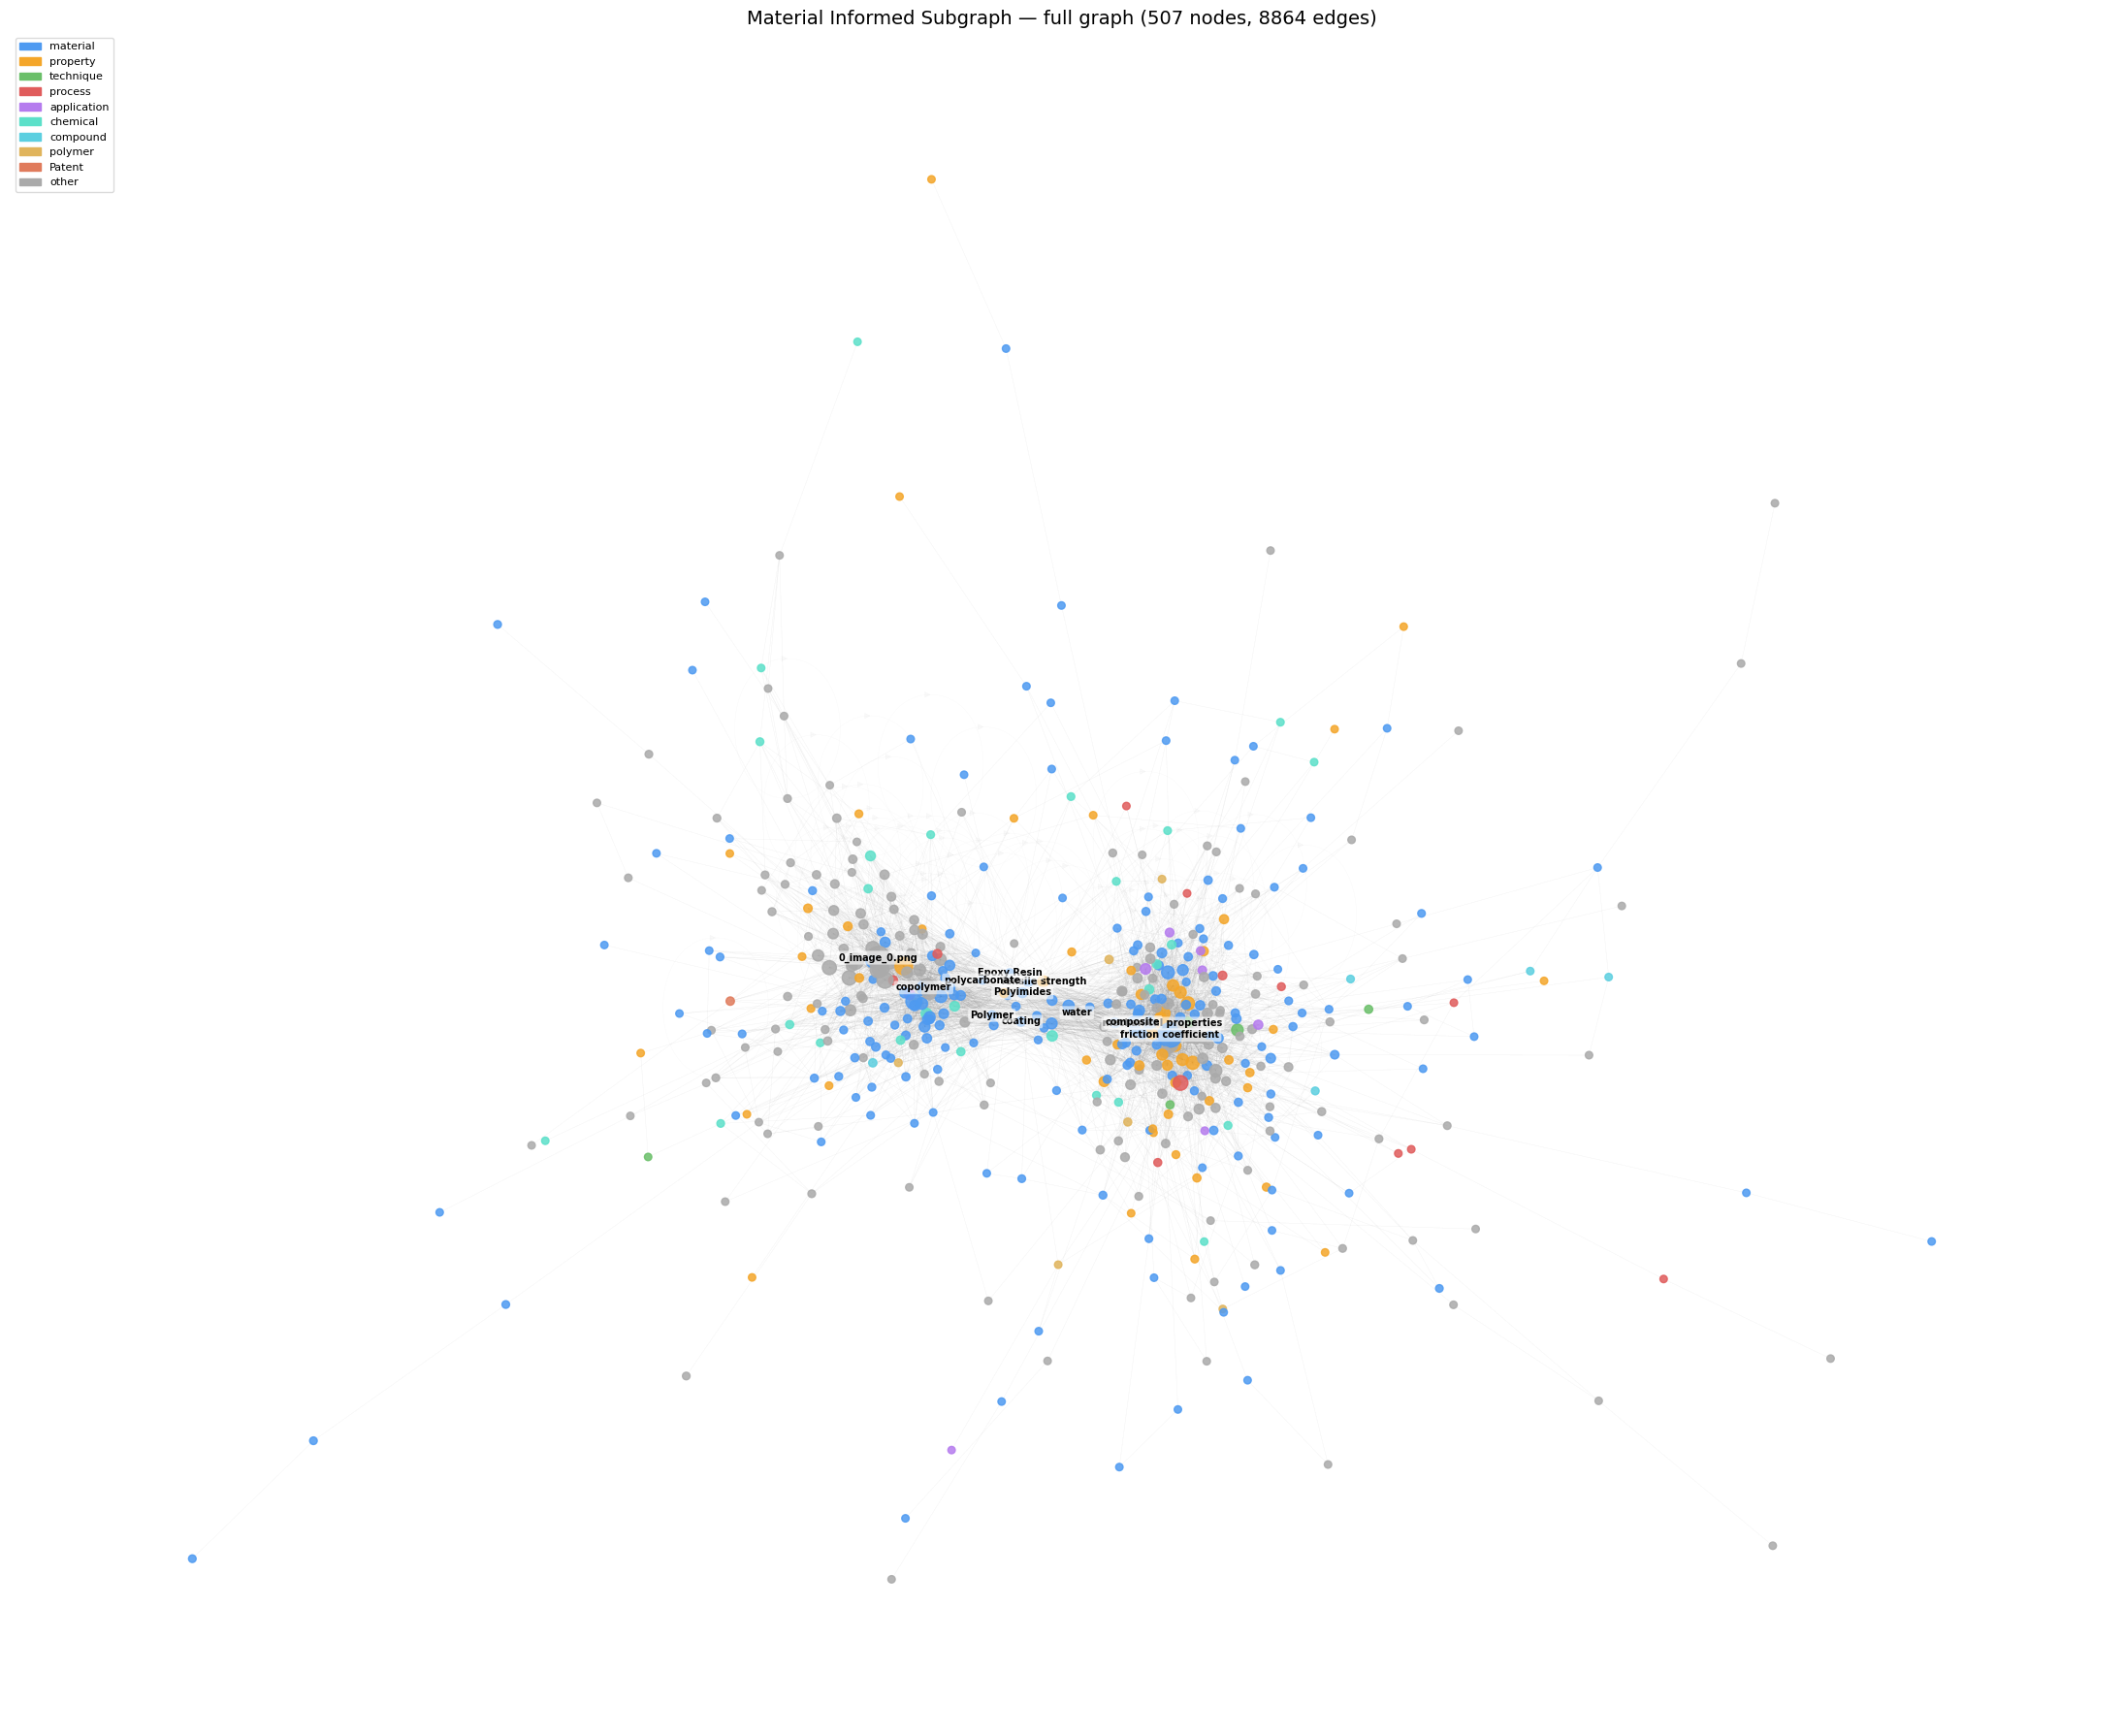

In [6]:
# ---- Full Material Informed Subgraph (high-level overview) ----
FULL_SEED    = 42
FULL_FIG_SIZE = (22, 18)
LABEL_TOP_N  = 12   # only name the highest-degree hubs

def full_node_color(n):
    t = G.nodes[n].get("type", "")
    for key, col in TYPE_COLORS.items():
        if key.lower() in t.lower():
            return col
    return DEFAULT_COLOR

full_colors  = [full_node_color(n) for n in G.nodes]
full_raw_sz  = np.array([G.nodes[n].get("size", 50) for n in G.nodes], dtype=float)
full_sizes   = 30 + 300 * (full_raw_sz - full_raw_sz.min()) / (full_raw_sz.max() - full_raw_sz.min() + 1e-9)

full_pos = nx.spring_layout(G, seed=FULL_SEED, iterations=40, k=1.5 / np.sqrt(len(G)))

fig, ax = plt.subplots(figsize=FULL_FIG_SIZE)

nx.draw_networkx_edges(G, full_pos, ax=ax, alpha=0.04, width=0.3,
                       edge_color="#666666", arrows=False)

nx.draw_networkx_nodes(G, full_pos, ax=ax,
                       node_color=full_colors, node_size=full_sizes, alpha=0.85)

top_labels = {n: n for n, _ in sorted(G.degree(), key=lambda x: x[1], reverse=True)[:LABEL_TOP_N]}
nx.draw_networkx_labels(G, full_pos, labels=top_labels, ax=ax,
                        font_size=7, font_weight="bold",
                        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, lw=0))

patches = [mpatches.Patch(color=col, label=t) for t, col in TYPE_COLORS.items()]
patches.append(mpatches.Patch(color=DEFAULT_COLOR, label="other"))
ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.7)

ax.set_title(
    f"Material Informed Subgraph — full graph ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)",
    fontsize=14
)
ax.axis("off")
plt.tight_layout()
plt.show()
